<a href="https://colab.research.google.com/github/Tushar3087/ML-Lab/blob/main/ml.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

✅ Dataset loaded successfully!

🔹 Sample Data (First 5 rows):
    Loan_ID Gender Married Dependents     Education Self_Employed  \
0  LP001002   Male      No          0      Graduate            No   
1  LP001003   Male     Yes          1      Graduate            No   
2  LP001005   Male     Yes          0      Graduate           Yes   
3  LP001006   Male     Yes          0  Not Graduate            No   
4  LP001008   Male      No          0      Graduate            No   

   ApplicantIncome  CoapplicantIncome  LoanAmount  Loan_Amount_Term  \
0             5849                0.0         NaN             360.0   
1             4583             1508.0       128.0             360.0   
2             3000                0.0        66.0             360.0   
3             2583             2358.0       120.0             360.0   
4             6000                0.0       141.0             360.0   

   Credit_History Property_Area Loan_Status  
0             1.0         Urban           Y  
1   

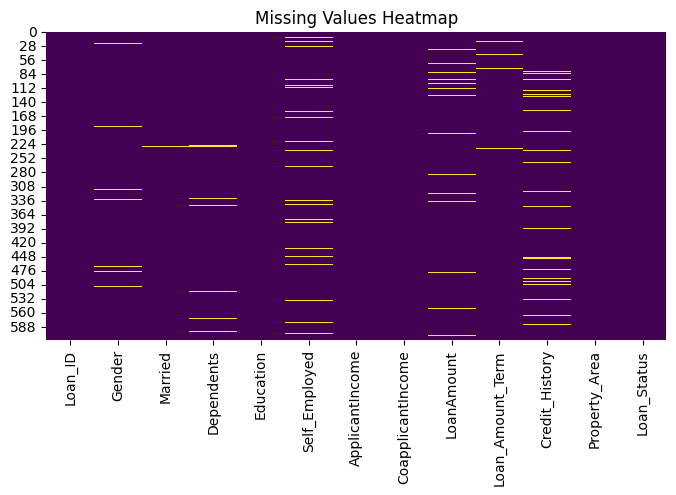


🔹 Duplicate Rows: 0


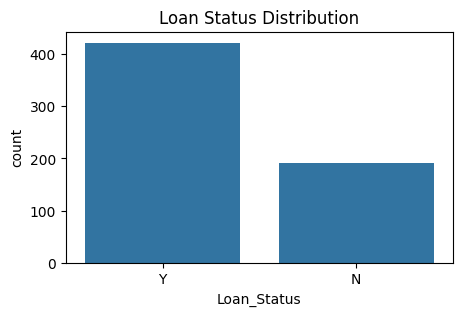

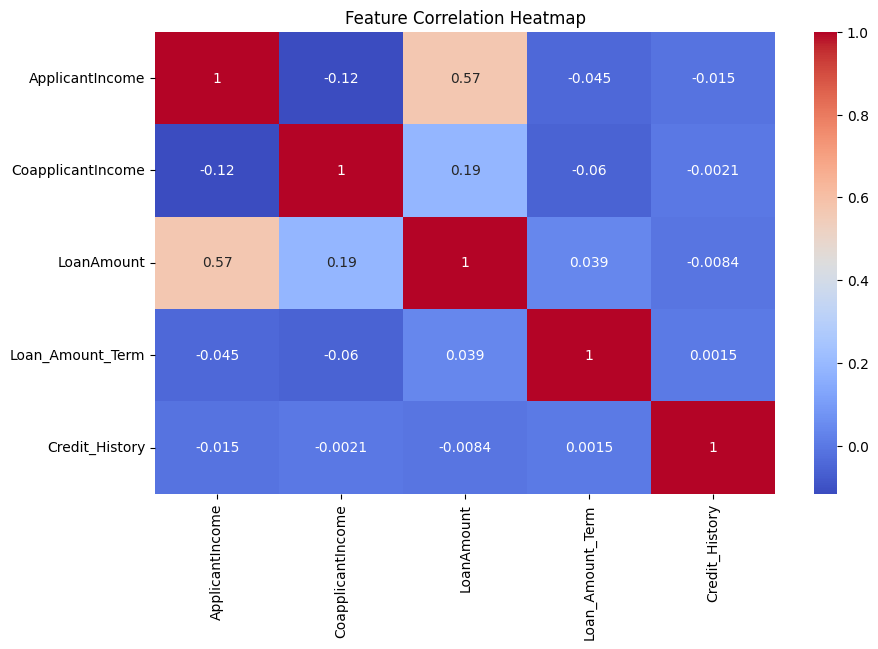

In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Load dataset
df = pd.read_csv("loan_prediction.csv")
print("✅ Dataset loaded successfully!\n")

# --------------------------------------------
# 🔹 Basic Overview
# --------------------------------------------
print("🔹 Sample Data (First 5 rows):")
print(df.head())

print("\n🔹 Dataset Shape:")
print("Rows:", df.shape[0], " | Columns:", df.shape[1])

# --------------------------------------------
# 🔹 Dataset Info
# --------------------------------------------
print("\n🔹 Dataset Info:")
df.info()

# --------------------------------------------
# 🔹 Summary Statistics
# --------------------------------------------
print("\n🔹 Summary Statistics (Numerical Columns):")
print(df.describe())

# --------------------------------------------
# 🔹 Missing Values Analysis
# --------------------------------------------
print("\n🔹 Missing Values:")
missing = df.isnull().sum()
print(missing[missing > 0])

# Visualize missing values
plt.figure(figsize=(8,4))
sns.heatmap(df.isnull(), cbar=False, cmap='viridis')
plt.title("Missing Values Heatmap")
plt.show()

# --------------------------------------------
# 🔹 Duplicate Check
# --------------------------------------------
duplicates = df.duplicated().sum()
print(f"\n🔹 Duplicate Rows: {duplicates}")

# --------------------------------------------
# 🔹 Target Variable Distribution
# --------------------------------------------
if 'Loan_Status' in df.columns:
    plt.figure(figsize=(5,3))
    sns.countplot(x='Loan_Status', data=df)
    plt.title("Loan Status Distribution")
    plt.show()

# --------------------------------------------
# 🔹 Correlation Heatmap (Numerical)
# --------------------------------------------
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.title("Feature Correlation Heatmap")
plt.show()


🔍 Missing Values (Before Handling):
Gender              13
Married              3
Dependents          15
Self_Employed       32
LoanAmount          22
Loan_Amount_Term    14
Credit_History      50
dtype: int64


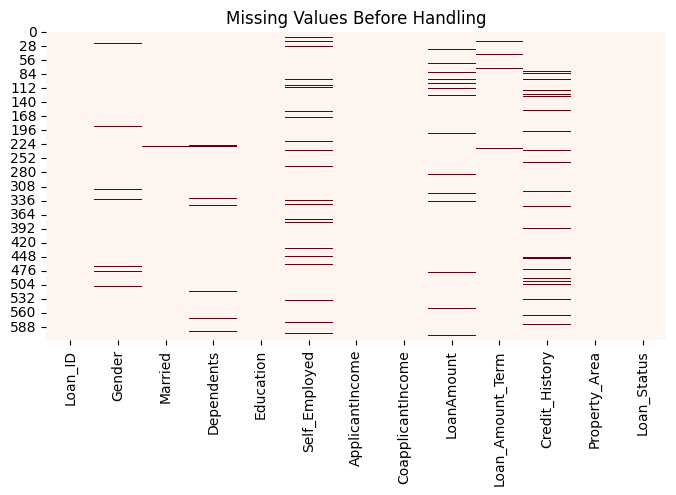

/tmp/ipykernel_757/1447059199.py:27: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].mode()[0], inplace=True)
/tmp/ipykernel_757/1447059199.py:30: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try u


✅ Missing Values (After Handling):
Series([], dtype: int64)


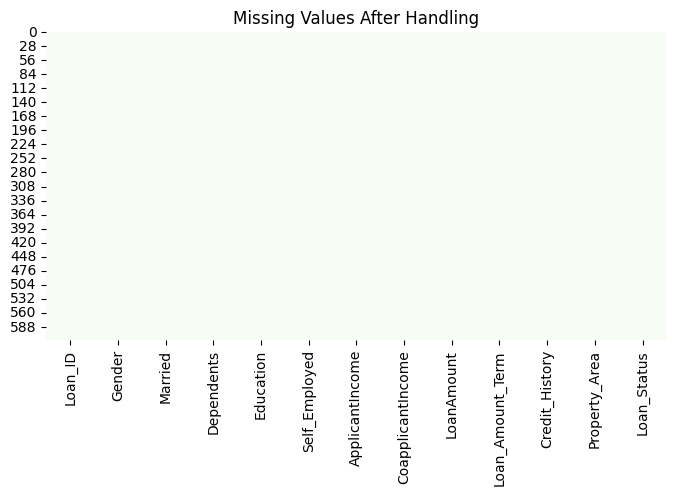

In [3]:
# --------------------------------------------
# 🔍 Missing Values Handling
# --------------------------------------------

# Check missing values BEFORE handling
print("\n🔍 Missing Values (Before Handling):")
missing_before = df.isnull().sum()
print(missing_before[missing_before > 0])

# Visualize missing values before
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,4))
sns.heatmap(df.isnull(), cbar=False, cmap='Reds')
plt.title("Missing Values Before Handling")
plt.show()

# --------------------------------------------
# 🛠️ Fill Missing Values
# --------------------------------------------

# Categorical columns → fill with MODE
categorical_cols = ['Gender', 'Married', 'Dependents', 'Self_Employed']

for col in categorical_cols:
    df[col].fillna(df[col].mode()[0], inplace=True)

# Numerical columns → fill with MEDIAN
df['LoanAmount'].fillna(df['LoanAmount'].median(), inplace=True)

# Mixed / special columns → MODE
df['Loan_Amount_Term'].fillna(df['Loan_Amount_Term'].mode()[0], inplace=True)
df['Credit_History'].fillna(df['Credit_History'].mode()[0], inplace=True)

# --------------------------------------------
# ✅ Verify Missing Values AFTER handling
# --------------------------------------------
print("\n✅ Missing Values (After Handling):")
missing_after = df.isnull().sum()
print(missing_after[missing_after > 0])

# Visualize after cleaning
plt.figure(figsize=(8,4))
sns.heatmap(df.isnull(), cbar=False, cmap='Greens')
plt.title("Missing Values After Handling")
plt.show()

In [4]:
from sklearn.preprocessing import LabelEncoder

# --------------------------------------------
# 🔤 Encoding Categorical Variables
# --------------------------------------------

# Drop unnecessary column
if 'Loan_ID' in df.columns:
    df.drop(columns=['Loan_ID'], inplace=True)
    print("🗑️ 'Loan_ID' column dropped (not useful for prediction)")

# Identify categorical columns
categorical_cols = [
    'Gender', 'Married', 'Education',
    'Self_Employed', 'Property_Area',
    'Dependents', 'Loan_Status'
]

# Show unique values BEFORE encoding
print("\n🔍 Unique Values Before Encoding:")
for col in categorical_cols:
    if col in df.columns:
        print(f"{col}: {df[col].unique()}")

# Apply Label Encoding
le = LabelEncoder()
for col in categorical_cols:
    if col in df.columns:
        df[col] = le.fit_transform(df[col])

# --------------------------------------------
# ✅ After Encoding
# --------------------------------------------
print("\n🔤 Encoded Data Sample:")
print(df.head())

# Check data types
print("\n📊 Data Types After Encoding:")
print(df.dtypes)

🗑️ 'Loan_ID' column dropped (not useful for prediction)

🔍 Unique Values Before Encoding:
Gender: ['Male' 'Female']
Married: ['No' 'Yes']
Education: ['Graduate' 'Not Graduate']
Self_Employed: ['No' 'Yes']
Property_Area: ['Urban' 'Rural' 'Semiurban']
Dependents: ['0' '1' '2' '3+']
Loan_Status: ['Y' 'N']

🔤 Encoded Data Sample:
   Gender  Married  Dependents  Education  Self_Employed  ApplicantIncome  \
0       1        0           0          0              0             5849   
1       1        1           1          0              0             4583   
2       1        1           0          0              1             3000   
3       1        1           0          1              0             2583   
4       1        0           0          0              0             6000   

   CoapplicantIncome  LoanAmount  Loan_Amount_Term  Credit_History  \
0                0.0       128.0             360.0             1.0   
1             1508.0       128.0             360.0             1.0   

In [5]:
from sklearn.model_selection import train_test_split

# --------------------------------------------
# 🔀 Split Dataset into Features & Target
# --------------------------------------------
X = df.drop(columns=['Loan_Status'])
y = df['Loan_Status']

print("\n📊 Original Dataset Shape:")
print("Features:", X.shape)
print("Target:", y.shape)

# --------------------------------------------
# 🔀 Train-Test Split (with Stratification)
# --------------------------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y   # 🔥 maintains class balance
)

# --------------------------------------------
# ✅ Split Summary
# --------------------------------------------
print("\n✅ Data Split Complete:")
print(f"Training Samples: {X_train.shape[0]}")
print(f"Testing Samples: {X_test.shape[0]}")

print("\n📊 Training Feature Shape:", X_train.shape)
print("📊 Testing Feature Shape:", X_test.shape)

# --------------------------------------------
# 🔍 Check Target Distribution (IMPORTANT)
# --------------------------------------------
print("\n🔍 Target Distribution (Train):")
print(y_train.value_counts(normalize=True))

print("\n🔍 Target Distribution (Test):")
print(y_test.value_counts(normalize=True))


📊 Original Dataset Shape:
Features: (614, 11)
Target: (614,)

✅ Data Split Complete:
Training Samples: 491
Testing Samples: 123

📊 Training Feature Shape: (491, 11)
📊 Testing Feature Shape: (123, 11)

🔍 Target Distribution (Train):
Loan_Status
1    0.686354
0    0.313646
Name: proportion, dtype: float64

🔍 Target Distribution (Test):
Loan_Status
1    0.691057
0    0.308943
Name: proportion, dtype: float64


In [6]:
from sklearn.preprocessing import StandardScaler

# --------------------------------------------
# ⚖️ Feature Scaling (Applied to ALL Models)
# --------------------------------------------

scaler = StandardScaler()

# Fit on training data and transform both
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("\n🔹 Feature Scaling applied to ALL models successfully!")

# Convert back to DataFrame (optional but cleaner for debugging)
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train.columns)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X_test.columns)

# Preview scaled data
print("\n📊 Scaled Feature Sample:")
print(X_train_scaled.head())


🔹 Feature Scaling applied to ALL models successfully!

📊 Scaled Feature Sample:
     Gender   Married  Dependents  Education  Self_Employed  ApplicantIncome  \
0  0.464054 -1.380335   -0.748586  -0.540468      -0.394074        -0.352802   
1  0.464054  0.724462    0.250207  -0.540468      -0.394074        -0.343346   
2  0.464054  0.724462    1.249000  -0.540468      -0.394074        -0.339471   
3  0.464054  0.724462    0.250207   1.850250      -0.394074        -0.445963   
4  0.464054  0.724462   -0.748586  -0.540468      -0.394074        -0.451078   

   CoapplicantIncome  LoanAmount  Loan_Amount_Term  Credit_History  \
0          -0.563228   -1.131588          0.280691        0.397516   
1          -0.563228   -0.592309          0.280691        0.397516   
2           0.050405    0.040758          0.280691       -2.515623   
3          -0.024953   -0.393010         -2.486768       -2.515623   
4           0.234495    0.040758          0.280691        0.397516   

   Property_Area 

In [7]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

log_model = LogisticRegression(max_iter=1000)
log_model.fit(X_train_scaled, y_train)
y_pred_log = log_model.predict(X_test_scaled)

print("\n📊 Logistic Regression Results:")
print("Accuracy:", accuracy_score(y_test, y_pred_log))
print("\nClassification Report:\n", classification_report(y_test, y_pred_log))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred_log))


📊 Logistic Regression Results:
Accuracy: 0.8617886178861789

Classification Report:
               precision    recall  f1-score   support

           0       0.96      0.58      0.72        38
           1       0.84      0.99      0.91        85

    accuracy                           0.86       123
   macro avg       0.90      0.78      0.81       123
weighted avg       0.88      0.86      0.85       123


Confusion Matrix:
 [[22 16]
 [ 1 84]]


In [11]:
from sklearn.svm import SVC

svm_model = SVC(kernel='rbf', random_state=42)
svm_model.fit(X_train_scaled, y_train)
y_pred_svm = svm_model.predict(X_test_scaled)

print("\n📊 SVM Results:")
print("Accuracy:", accuracy_score(y_test, y_pred_svm))
print("\nClassification Report:\n", classification_report(y_test, y_pred_svm))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred_svm))


📊 SVM Results:
Accuracy: 0.8536585365853658

Classification Report:
               precision    recall  f1-score   support

           0       0.95      0.55      0.70        38
           1       0.83      0.99      0.90        85

    accuracy                           0.85       123
   macro avg       0.89      0.77      0.80       123
weighted avg       0.87      0.85      0.84       123


Confusion Matrix:
 [[21 17]
 [ 1 84]]


In [10]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(n_estimators=200, random_state=42)
rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)

print("\n📊 Random Forest Results:")
print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print("\nClassification Report:\n", classification_report(y_test, y_pred_rf))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred_rf))


📊 Random Forest Results:
Accuracy: 0.8373983739837398

Classification Report:
               precision    recall  f1-score   support

           0       0.80      0.63      0.71        38
           1       0.85      0.93      0.89        85

    accuracy                           0.84       123
   macro avg       0.82      0.78      0.80       123
weighted avg       0.83      0.84      0.83       123


Confusion Matrix:
 [[24 14]
 [ 6 79]]


In [9]:
from sklearn.tree import DecisionTreeClassifier

dt_model = DecisionTreeClassifier(random_state=42, max_depth=5)
dt_model.fit(X_train_scaled, y_train)
y_pred_dt = dt_model.predict(X_test_scaled)

print("\n📊 Decision Tree Results:")
print("Accuracy:", accuracy_score(y_test, y_pred_dt))
print("\nClassification Report:\n", classification_report(y_test, y_pred_dt))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred_dt))


📊 Decision Tree Results:
Accuracy: 0.8211382113821138

Classification Report:
               precision    recall  f1-score   support

           0       0.81      0.55      0.66        38
           1       0.82      0.94      0.88        85

    accuracy                           0.82       123
   macro avg       0.82      0.75      0.77       123
weighted avg       0.82      0.82      0.81       123


Confusion Matrix:
 [[21 17]
 [ 5 80]]


In [8]:
from sklearn.naive_bayes import GaussianNB

nb_model = GaussianNB()
nb_model.fit(X_train_scaled, y_train)
y_pred_nb = nb_model.predict(X_test_scaled)

print("\n📊 Naive Bayes Results:")
print("Accuracy:", accuracy_score(y_test, y_pred_nb))
print("\nClassification Report:\n", classification_report(y_test, y_pred_nb))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred_nb))


📊 Naive Bayes Results:
Accuracy: 0.8455284552845529

Classification Report:
               precision    recall  f1-score   support

           0       0.88      0.58      0.70        38
           1       0.84      0.96      0.90        85

    accuracy                           0.85       123
   macro avg       0.86      0.77      0.80       123
weighted avg       0.85      0.85      0.84       123


Confusion Matrix:
 [[22 16]
 [ 3 82]]


In [12]:
# --------------------------------------------
# 📊 Model Comparison (ALL 5 MODELS)
# --------------------------------------------

results = pd.DataFrame({
    'Model': [
        'Logistic Regression',
        'Support Vector Machine',
        'Random Forest',
        'Decision Tree',
        'Naive Bayes'
    ],
    'Accuracy': [
        accuracy_score(y_test, y_pred_log),
        accuracy_score(y_test, y_pred_svm),
        accuracy_score(y_test, y_pred_rf),
        accuracy_score(y_test, y_pred_dt),
        accuracy_score(y_test, y_pred_nb)
    ]
})

# Sort by best accuracy
results = results.sort_values(by='Accuracy', ascending=False)

# Reset index for clean display
results.reset_index(drop=True, inplace=True)

print("\n✅ Model Comparison Table (Sorted by Accuracy):")
print(results)

# --------------------------------------------
# 🏆 Best Model
# --------------------------------------------
best_model = results.iloc[0]

print("\n🏆 Best Model:")
print(f"Model: {best_model['Model']}")
print(f"Accuracy: {best_model['Accuracy']:.4f}")


✅ Model Comparison Table (Sorted by Accuracy):
                    Model  Accuracy
0     Logistic Regression  0.861789
1  Support Vector Machine  0.853659
2             Naive Bayes  0.845528
3           Random Forest  0.837398
4           Decision Tree  0.821138

🏆 Best Model:
Model: Logistic Regression
Accuracy: 0.8618


/tmp/ipykernel_757/2385180582.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
/tmp/ipykernel_757/2385180582.py:28: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


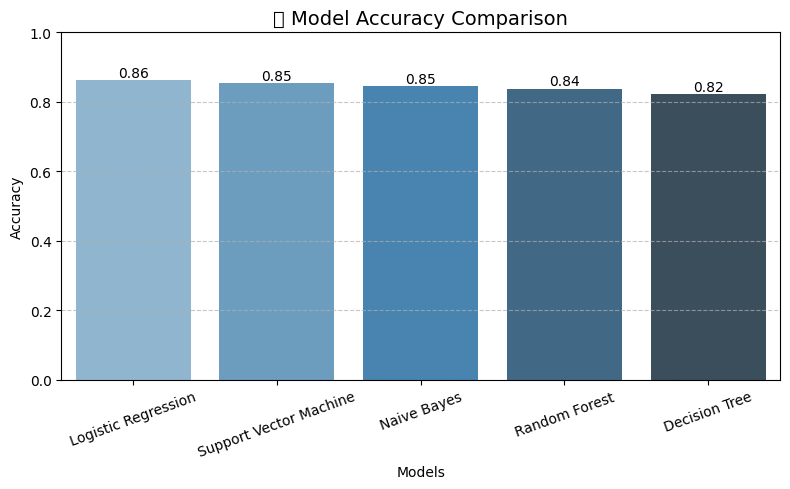

In [13]:
import seaborn as sns
import matplotlib.pyplot as plt

# --------------------------------------------
# 📊 Model Accuracy Comparison Plot
# --------------------------------------------
plt.figure(figsize=(8,5))

sns.barplot(
    x='Model',
    y='Accuracy',
    data=results,
    palette='Blues_d'
)

# Add accuracy values on top of bars
for index, value in enumerate(results['Accuracy']):
    plt.text(index, value + 0.01, f"{value:.2f}", ha='center', fontsize=10)

plt.title("📊 Model Accuracy Comparison", fontsize=14)
plt.xlabel("Models")
plt.ylabel("Accuracy")
plt.xticks(rotation=20)
plt.ylim(0, 1)

plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

/tmp/ipykernel_757/457978455.py:40: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


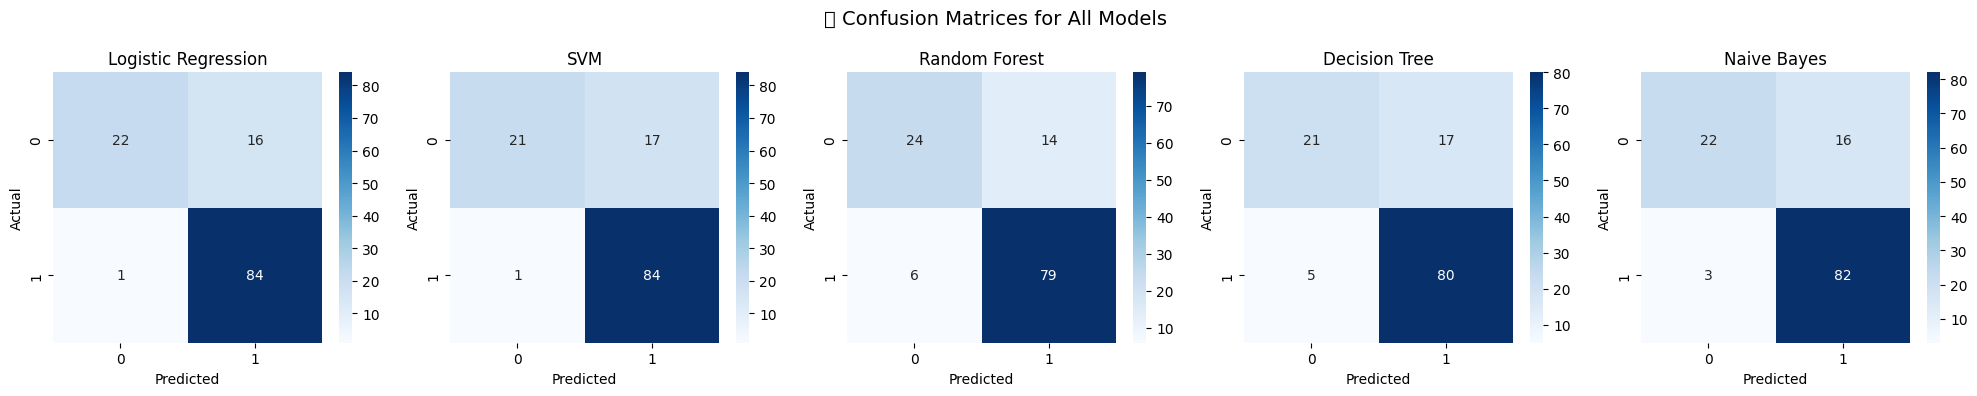

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# --------------------------------------------
# 🧩 Confusion Matrices for ALL 5 Models
# --------------------------------------------

fig, axes = plt.subplots(1, 5, figsize=(20, 4))

models = [
    'Logistic Regression',
    'SVM',
    'Random Forest',
    'Decision Tree',
    'Naive Bayes'
]

preds = [
    y_pred_log,
    y_pred_svm,
    y_pred_rf,
    y_pred_dt,
    y_pred_nb
]

for ax, model_name, pred in zip(axes, models, preds):
    sns.heatmap(
        confusion_matrix(y_test, pred),
        annot=True,
        fmt='d',
        cmap='Blues',
        ax=ax
    )
    ax.set_title(model_name)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")

plt.suptitle("📊 Confusion Matrices for All Models", fontsize=14)
plt.tight_layout()
plt.show()

| Output               | Code Section | What You’ll See                                      |
|----------------------|-------------|------------------------------------------------------|
| Dataset Info         | 1️⃣          | Head, info, describe                                 |
| Missing Values       | 2️⃣          | Before & after cleaning                              |
| Encoded Data         | 3️⃣          | Numeric encoded columns                              |
| Split Details        | 4️⃣          | Train/test sample sizes + class distribution         |
| Feature Scaling      | 5️⃣          | Standardized feature values                          |
| Logistic Regression  | 6️⃣          | Accuracy + Report + Confusion Matrix                 |
| SVM                  | 7️⃣          | Accuracy + Report + Confusion Matrix                 |
| Random Forest        | 8️⃣          | Accuracy + Report + Confusion Matrix                 |
| Decision Tree        | 9️⃣          | Accuracy + Report + Confusion Matrix                 |
| Naive Bayes          | 🔟          | Accuracy + Report + Confusion Matrix                 |
| Comparison Table     | 1️⃣1️⃣        | Sorted accuracy summary + best model                 |
| Visualization        | 1️⃣2️⃣, 1️⃣3️⃣ | Accuracy bar chart + all 5 confusion matrices        |